In [25]:
import pandas as pd 
import numpy as np 

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os
import random
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# --- continue after your existing code (right after fitting dt_tda and dt_prl) ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np


In [3]:
import pandas as pd 
import numpy as np 

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [19]:
network_list = [
    'conf','email_eu_modified','school','barabasi_albert'
]
network_list = [
'school'
]

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os

def confidence_interval(accuracy, n, confidence=0.95):
    std_error = np.sqrt(accuracy * (1 - accuracy) / n)
    z_score = stats.norm.ppf((1 + confidence) / 2)
    margin_of_error = z_score * std_error
    return (accuracy - margin_of_error, accuracy + margin_of_error)


In [23]:
prob_complex = 0.02
for network_name in network_list:
    #read and preprocessing data
    df1 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_2_prob_{prob_complex}_EPH-v3.csv")
    df2 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_3_prob_{prob_complex}_EPH-v3.csv")
    df3 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_4_prob_{prob_complex}_EPH-v3.csv")
    df4 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_5_prob_{prob_complex}_EPH-v3.csv")
    df5 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_6_prob_{prob_complex}_EPH-v3.csv")
    df6 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_7_prob_{prob_complex}_EPH-v3.csv")

    df8 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.02_EPH-v3.csv")
    df9 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.03_EPH-v3.csv")
    df10 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.04_EPH-v3.csv")
    df11 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.05_EPH-v3.csv")

    df1['theta'] = 2 
    df2['theta'] = 3 
    df3['theta'] = 4 
    df4['theta'] = 5 
    df5['theta'] = 6 
    df6['theta'] = 7 

    complex_c = pd.concat([df1,df2])
    complex_c = pd.concat([complex_c,df3])
    complex_c = pd.concat([complex_c,df4])
    complex_c = pd.concat([complex_c,df5])
    complex_c = pd.concat([complex_c,df6])
    complex_c = complex_c.sample(frac=1,random_state=42)

    simple_c = pd.concat([df8,df9])
    simple_c = pd.concat([simple_c,df10])
    simple_c = pd.concat([simple_c,df11])
    simple_c = simple_c.sample(frac=1,random_state=42)
    # Lists to store results
    threshold_set = [2,3,4,5,6,7]
    accuracies_tda = []
    ci_lower_tda = []
    ci_upper_tda = []
    accuracies_prl = []
    ci_lower_prl = []
    ci_upper_prl = []

    for th in threshold_set:
        # Prepare data
        complex_curr = complex_c[complex_c['theta'] == th]
        complex_curr = complex_curr[['EPH','corr']]
        complex_curr['complex'] = 1

        simple_curr = simple_c[['EPH','corr']]
        simple_curr['complex'] = 0

        if len(simple_curr) > len(complex_curr):
            simple_curr = simple_curr.sample(len(complex_curr),random_state=1242)
        else:
            complex_curr = complex_curr.sample(len(simple_curr),random_state=1242)

        merged = pd.concat([simple_curr,complex_curr])
        merged = merged.sample(len(merged),random_state=1)

        X_tda = merged['EPH']
        X_prl = merged['corr']
        y = merged['complex']

        # Split data
        X_tda_train, X_tda_test, y_tda_train, y_tda_test = train_test_split(X_tda, y, test_size=0.2, random_state=42)
        X_prl_train, X_prl_test, y_prl_train, y_prl_test = train_test_split(X_prl, y, test_size=0.2, random_state=42)

        # Train and evaluate models
        dt_tda = DecisionTreeClassifier(random_state=42)
        dt_prl = DecisionTreeClassifier(random_state=42)

        dt_tda.fit(X_tda_train.values.reshape(-1, 1), y_tda_train)
        dt_prl.fit(X_prl_train.values.reshape(-1, 1), y_prl_train)

        y_tda_pred = dt_tda.predict(X_tda_test.values.reshape(-1, 1))
        y_prl_pred = dt_prl.predict(X_prl_test.values.reshape(-1, 1))

        accuracy_tda = accuracy_score(y_tda_test, y_tda_pred)
        accuracy_prl = accuracy_score(y_prl_test, y_prl_pred)

        # Calculate confidence intervals
        ci_tda = confidence_interval(accuracy_tda, len(y_tda_test))
        ci_prl = confidence_interval(accuracy_prl, len(y_prl_test))

        # Store results
        accuracies_tda.append(accuracy_tda)
        ci_lower_tda.append(ci_tda[0])
        ci_upper_tda.append(min(1,ci_tda[1]))
        accuracies_prl.append(accuracy_prl)
        ci_lower_prl.append(ci_prl[0])
        ci_upper_prl.append(min(1,ci_prl[1]))

    # Create the plot
    plt.figure(figsize=(10, 7), dpi=1200)

    plt.plot(threshold_set, accuracies_tda, marker='o', label='EPH')
    plt.fill_between(threshold_set, ci_lower_tda, ci_upper_tda, alpha=0.2)

    plt.plot(threshold_set, accuracies_prl, marker='s', label='corr(order,deg)')
    plt.fill_between(threshold_set, ci_lower_prl, ci_upper_prl, alpha=0.2)

    # Set x-axis to show only integer values
    plt.xticks(threshold_set)


    plt.xlabel('Threshold (θ)',fontsize=15)
    plt.ylabel('Accuracy',fontsize=15)
    plt.legend(loc='lower right',fontsize=15)

    # plt.ylim(0.90,1.01)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # plt.grid(True)

    plt.tight_layout()

    # Save the plot
    plt.savefig(f'fig2-panelA_{network_name}_q={prob_complex}.pdf', format='pdf', dpi=1200, bbox_inches='tight')
    plt.close()  # Close the plot to free up memory


/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_15918/1276230870.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_15918/1276230870.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_15918/1276230870.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_15918/1234830991.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complex_curr['complex'] = 1
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_15918/1234830991.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0


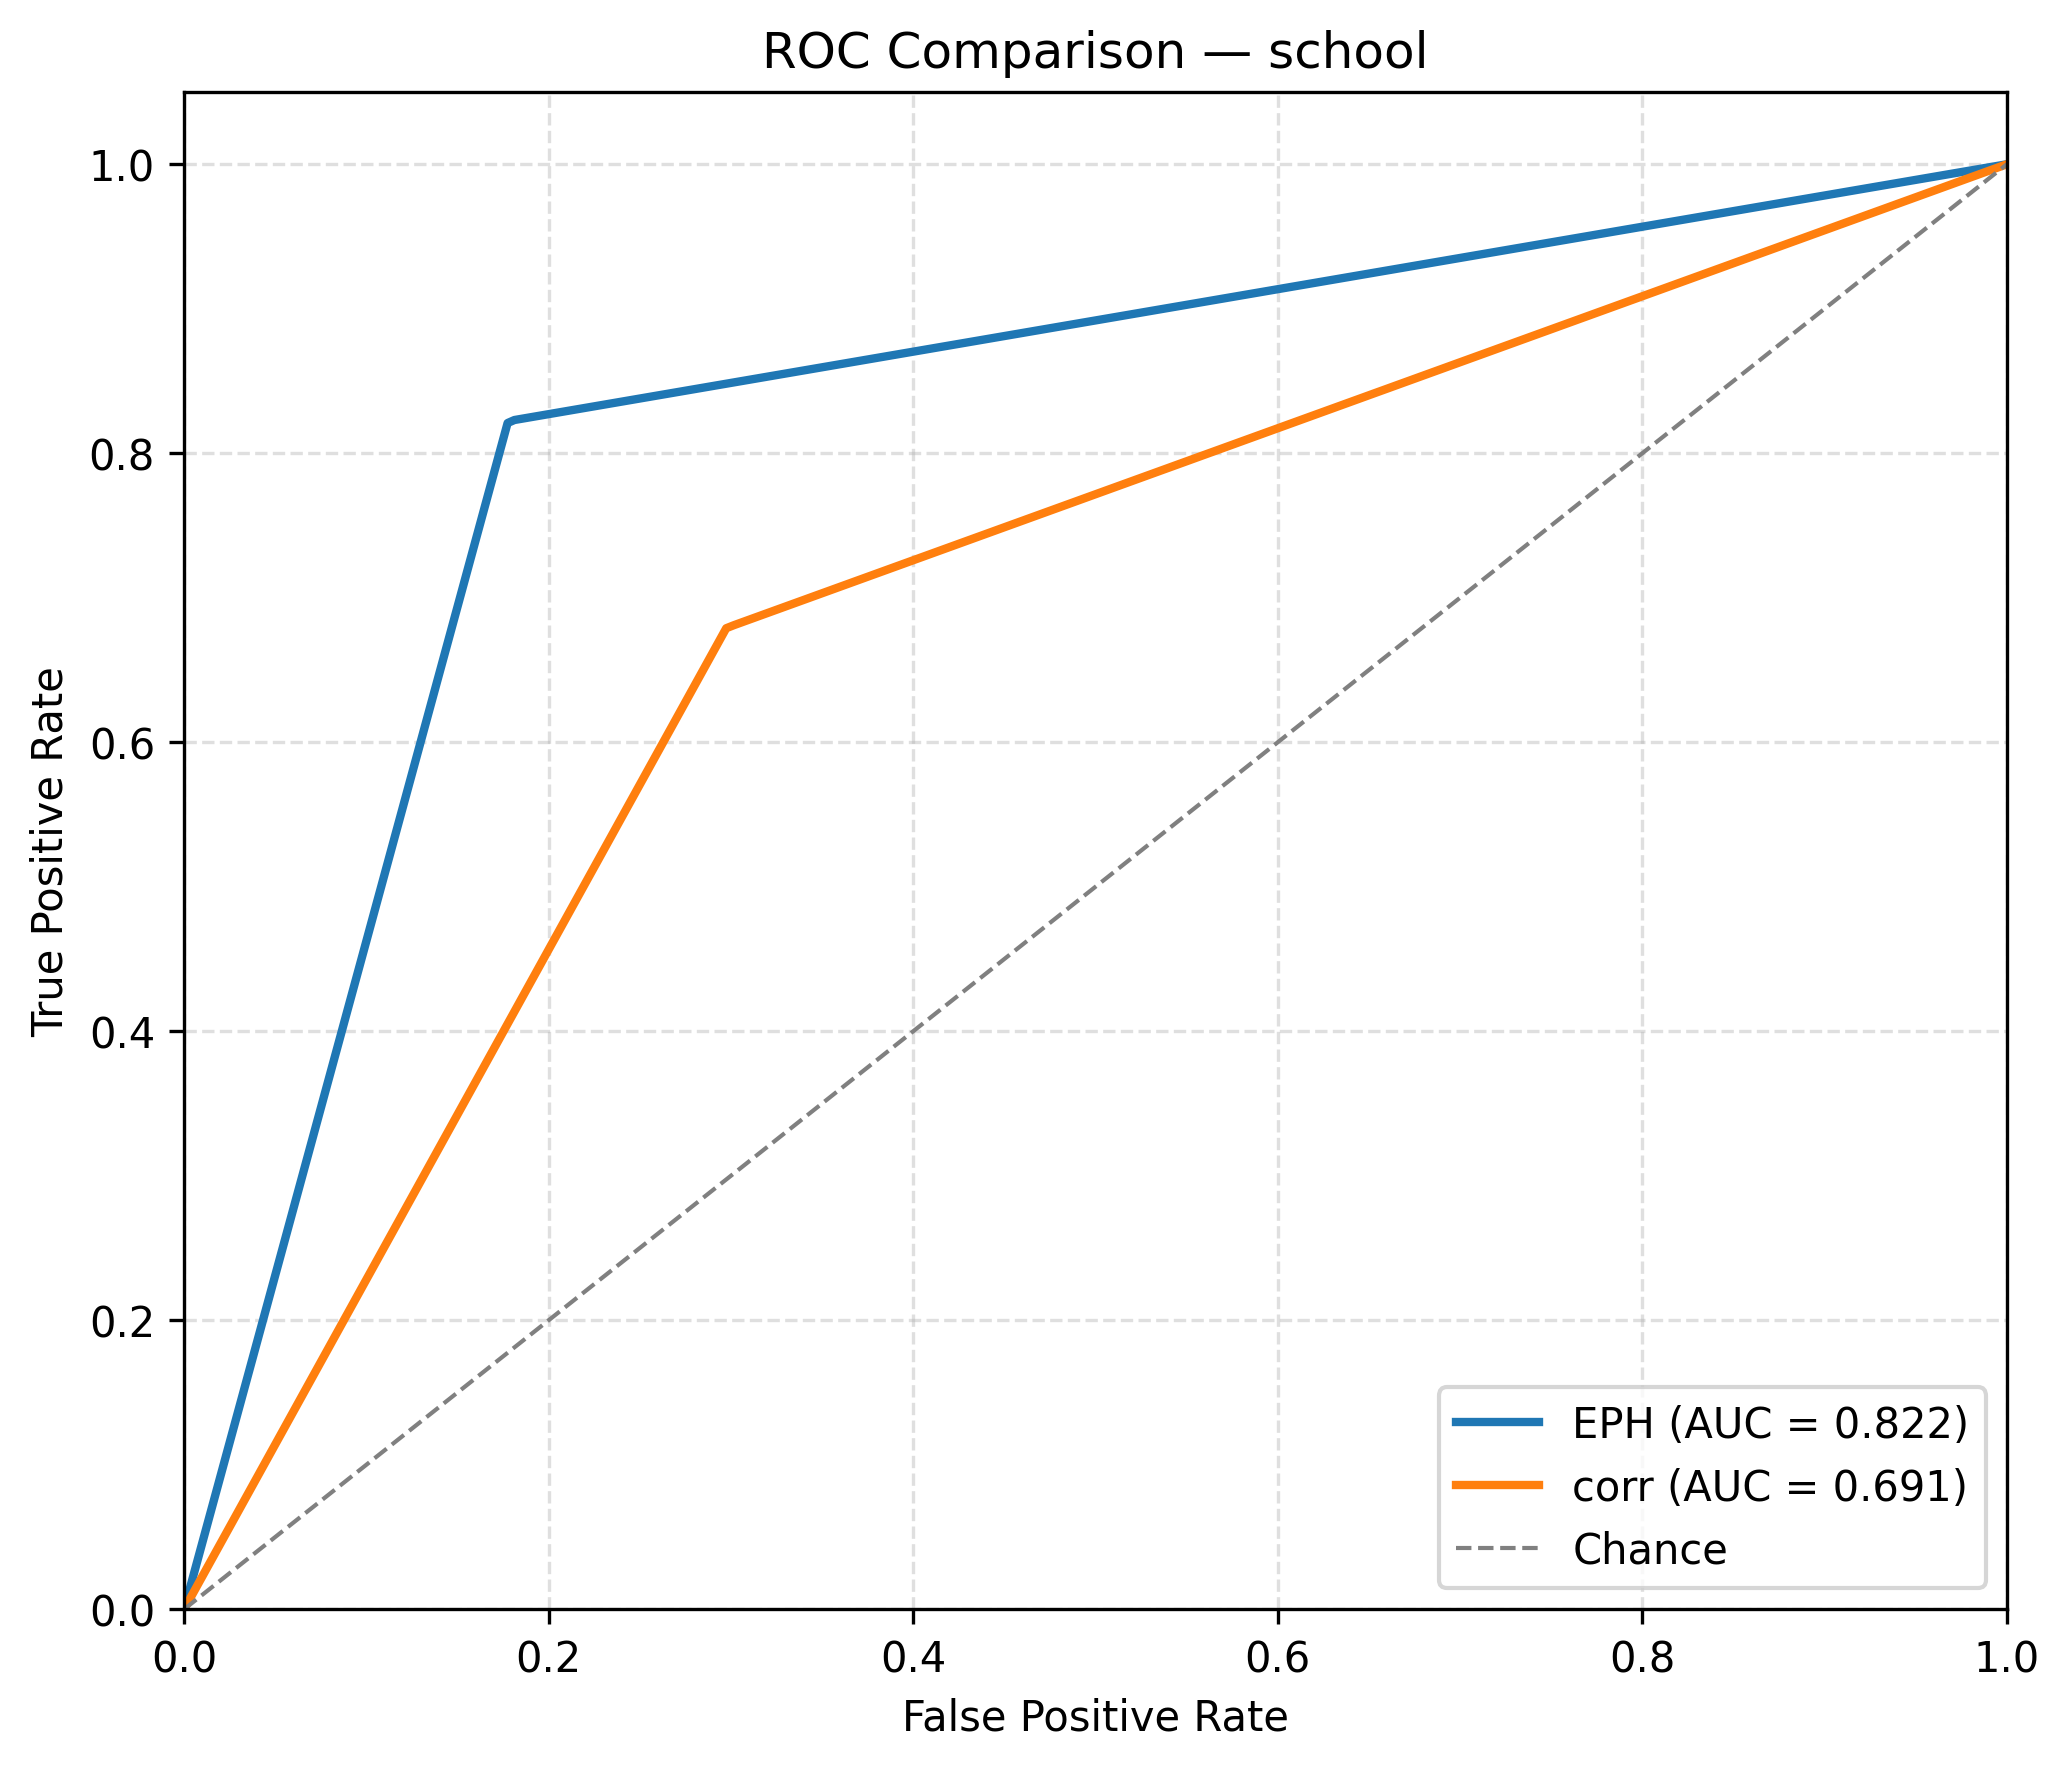

AUC (EPH):  0.8223
AUC (corr): 0.6908


In [27]:
prob_complex = 0.02
for network_name in network_list:
    #read and preprocessing data
    df1 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_2_prob_{prob_complex}_EPH-v3.csv")
    df2 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_3_prob_{prob_complex}_EPH-v3.csv")
    df3 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_4_prob_{prob_complex}_EPH-v3.csv")
    df4 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_5_prob_{prob_complex}_EPH-v3.csv")
    df5 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_6_prob_{prob_complex}_EPH-v3.csv")
    df6 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_7_prob_{prob_complex}_EPH-v3.csv")

    df8 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.02_EPH-v3.csv")
    df9 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.03_EPH-v3.csv")
    df10 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.04_EPH-v3.csv")
    df11 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.05_EPH-v3.csv")

    complex_c = pd.concat([df1,df2])
    complex_c = pd.concat([complex_c,df3])
    complex_c = pd.concat([complex_c,df4])
    complex_c = pd.concat([complex_c,df5])
    complex_c = pd.concat([complex_c,df6])
    complex_c = complex_c.sample(frac=1,random_state=42)

    simple_c = pd.concat([df8,df9])
    simple_c = pd.concat([simple_c,df10])
    simple_c = pd.concat([simple_c,df11])
    simple_c = simple_c.sample(frac=1,random_state=42)


    complex_curr = complex_c[['EPH','corr']]
    complex_curr['complex'] = 1

    simple_curr = simple_c[['EPH','corr']]
    simple_curr['complex'] = 0

    if len(simple_curr) > len(complex_curr):
        simple_curr = simple_curr.sample(len(complex_curr),random_state=1242)
    else:
        complex_curr = complex_curr.sample(len(simple_curr),random_state=1242)

    merged = pd.concat([simple_curr,complex_curr])
    merged = merged.sample(len(merged),random_state=1)


    # Use a single, consistent split for a fair comparison
    # Rebuild X and y as arrays first
    X_tda = merged[['EPH']].values
    X_prl = merged[['corr']].values
    y = merged['complex'].values
    
    idx_train, idx_test = train_test_split(
        np.arange(len(y)),
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    X_tda_train, X_tda_test = X_tda[idx_train], X_tda[idx_test]
    X_prl_train, X_prl_test = X_prl[idx_train], X_prl[idx_test]
    y_train, y_test = y[idx_train], y[idx_test]
    
    # Refit on the consistent split
    dt_tda = DecisionTreeClassifier(random_state=42)
    dt_prl = DecisionTreeClassifier(random_state=42)
    
    dt_tda.fit(X_tda_train, y_train)
    dt_prl.fit(X_prl_train, y_train)
    
    # Predict probabilities for ROC (positive class = 1)
    y_score_tda = dt_tda.predict_proba(X_tda_test)[:, 1]
    y_score_prl = dt_prl.predict_proba(X_prl_test)[:, 1]
    
    # Compute ROC curves and AUCs
    fpr_tda, tpr_tda, _ = roc_curve(y_test, y_score_tda)
    fpr_prl, tpr_prl, _ = roc_curve(y_test, y_score_prl)
    auc_tda = auc(fpr_tda, tpr_tda)
    auc_prl = auc(fpr_prl, tpr_prl)
    
    # Plot both ROC curves together
    plt.figure(figsize=(7, 6), dpi=300)
    plt.plot(fpr_tda, tpr_tda, lw=2, label=f'EPH (AUC = {auc_tda:.3f})')
    plt.plot(fpr_prl, tpr_prl, lw=2, label=f'corr (AUC = {auc_prl:.3f})')
    
    # Chance diagonal
    plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='gray', label='Chance')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Comparison — {network_name}')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    print(f"AUC (EPH):  {auc_tda:.4f}")
    print(f"AUC (corr): {auc_prl:.4f}")



/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_15918/156493296.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complex_curr['complex'] = 1
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_15918/156493296.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0


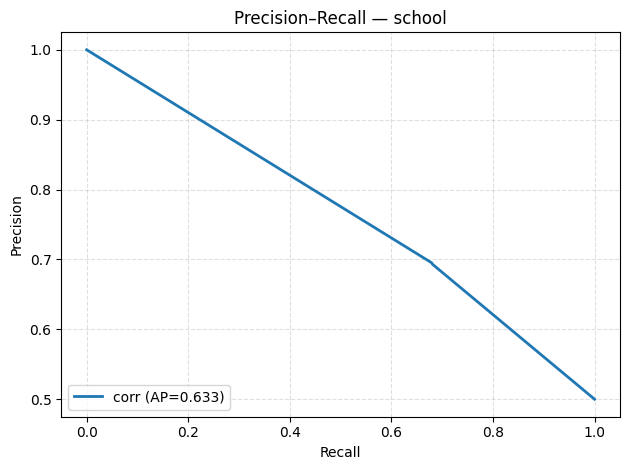

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
prob_complex = 0.02
for network_name in network_list:
    #read and preprocessing data
    df1 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_2_prob_{prob_complex}_EPH-v3.csv")
    df2 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_3_prob_{prob_complex}_EPH-v3.csv")
    df3 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_4_prob_{prob_complex}_EPH-v3.csv")
    df4 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_5_prob_{prob_complex}_EPH-v3.csv")
    df5 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_6_prob_{prob_complex}_EPH-v3.csv")
    df6 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_complex_{network_name}_theta_7_prob_{prob_complex}_EPH-v3.csv")

    df8 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.02_EPH-v3.csv")
    df9 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.03_EPH-v3.csv")
    df10 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.04_EPH-v3.csv")
    df11 = pd.read_csv(f"./result_supplementary/unweighted/unweighted_simple_{network_name}_beta_0.05_EPH-v3.csv")

    complex_c = pd.concat([df1,df2])
    complex_c = pd.concat([complex_c,df3])
    complex_c = pd.concat([complex_c,df4])
    complex_c = pd.concat([complex_c,df5])
    complex_c = pd.concat([complex_c,df6])
    complex_c = complex_c.sample(frac=1,random_state=42)

    simple_c = pd.concat([df8,df9])
    simple_c = pd.concat([simple_c,df10])
    simple_c = pd.concat([simple_c,df11])
    simple_c = simple_c.sample(frac=1,random_state=42)


    complex_curr = complex_c[['EPH','corr']]
    complex_curr['complex'] = 1

    simple_curr = simple_c[['EPH','corr']]
    simple_curr['complex'] = 0

    if len(simple_curr) > len(complex_curr):
        simple_curr = simple_curr.sample(len(complex_curr),random_state=1242)
    else:
        complex_curr = complex_curr.sample(len(simple_curr),random_state=1242)

    merged = pd.concat([simple_curr,complex_curr])
    merged = merged.sample(len(merged),random_state=1)


    # Use a single, consistent split for a fair comparison
    # Rebuild X and y as arrays first
    X_tda = merged[['EPH']].values
    X_prl = merged[['corr']].values
    y = merged['complex'].values
    
    idx_train, idx_test = train_test_split(
        np.arange(len(y)),
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    X_tda_train, X_tda_test = X_tda[idx_train], X_tda[idx_test]
    X_prl_train, X_prl_test = X_prl[idx_train], X_prl[idx_test]
    y_train, y_test = y[idx_train], y[idx_test]
    
    # Refit on the consistent split
    dt_tda = DecisionTreeClassifier(random_state=42)
    dt_prl = DecisionTreeClassifier(random_state=42)
    
    dt_tda.fit(X_tda_train, y_train)
    dt_prl.fit(X_prl_train, y_train)
    
    for name, scores in [("EPH", y_score_tda), ("corr", y_score_prl)]:
        prec, rec, _ = precision_recall_curve(y_test, scores)
        ap = average_precision_score(y_test, scores)
    plt.plot(rec, prec, lw=2, label=f"{name} (AP={ap:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall — {network_name}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()
